# Customer Behavior Analysis in E‑commerce
**Flipshope Analytics Assignment**

Author: Raju Sewda

This notebook explores customer behavior on an e‑commerce platform using the provided dataset. The analysis focuses on understanding demographics, spending patterns, satisfaction levels, and engagement metrics to generate actionable insights for improving customer experience and retention.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize']=(8,5)

## 2. Load Dataset

In [2]:
df = pd.read_csv('customer_behavior.csv')
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


### Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [4]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


**Observation:** The dataset contains customer demographics, spending behavior, engagement indicators, and satisfaction ratings.

## 3. Data Cleaning

In [5]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [6]:
df = df.dropna()

Convert categorical columns for analysis.

In [7]:
cat_cols=['Gender','City','Membership Type','Satisfaction Level']
for col in cat_cols:
    df[col]=df[col].astype('category')

## 4. Customer Demographics

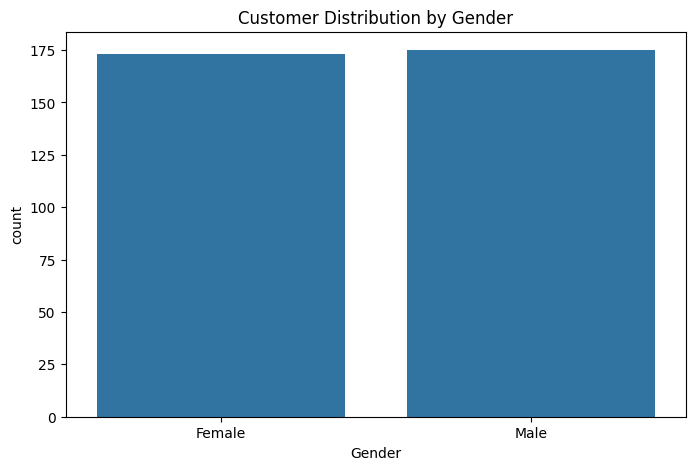

In [8]:
sns.countplot(x='Gender',data=df)
plt.title('Customer Distribution by Gender')
plt.show()

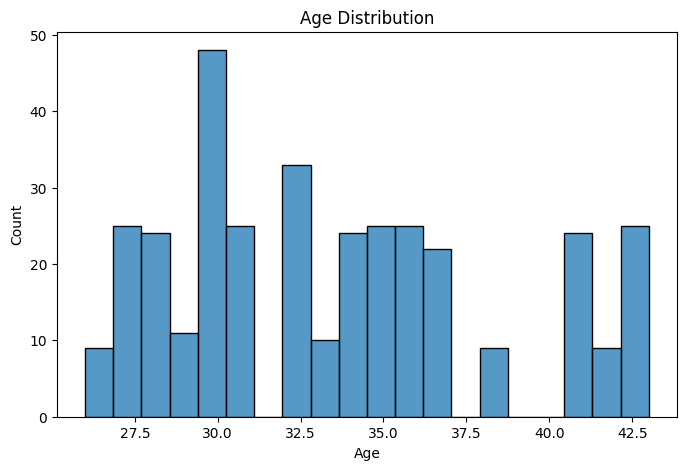

In [9]:
sns.histplot(df['Age'],bins=20)
plt.title('Age Distribution')
plt.show()

## 5. Membership Segmentation

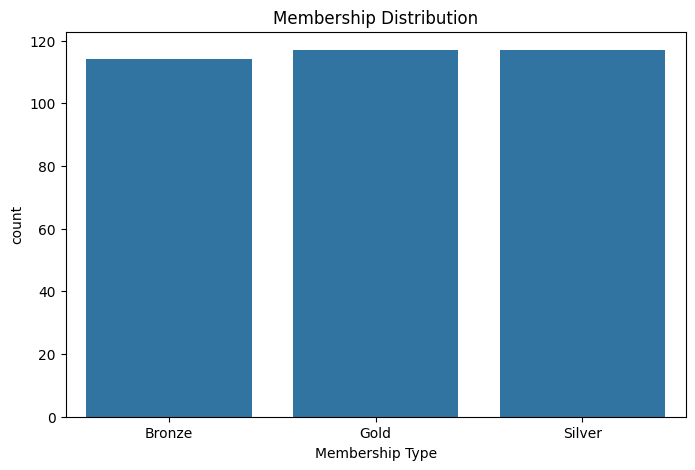

In [10]:
sns.countplot(x='Membership Type',data=df)
plt.title('Membership Distribution')
plt.show()

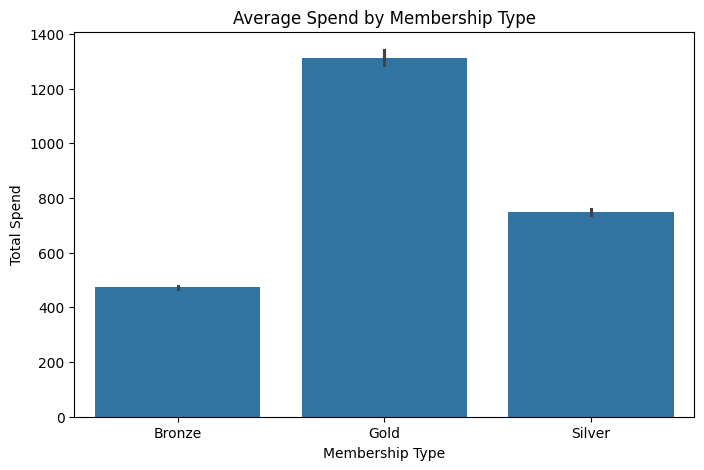

In [11]:
sns.barplot(x='Membership Type',y='Total Spend',data=df)
plt.title('Average Spend by Membership Type')
plt.show()

**Insight:** Premium members tend to spend more on average, indicating that membership tiers influence purchasing behavior.

## 6. Geographic Spending

/var/folders/v_/wkcsk_z90y39ny4k7k1v162w0000gn/T/ipykernel_12665/748977146.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_spend=df.groupby('City')['Total Spend'].mean().sort_values(ascending=False)


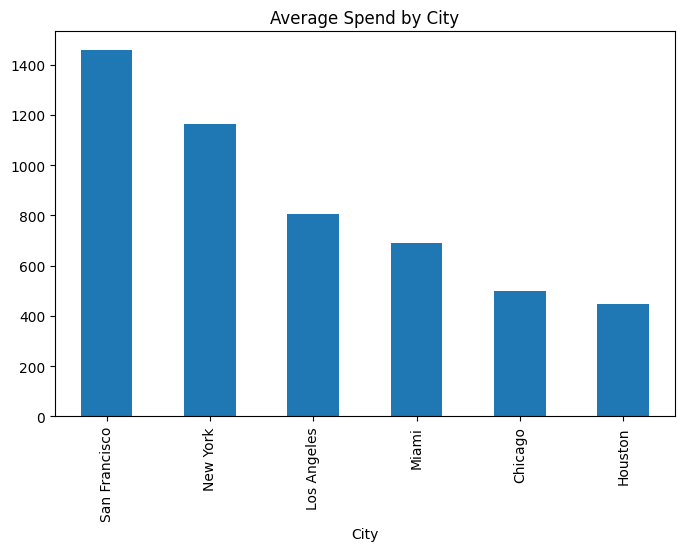

In [12]:
city_spend=df.groupby('City')['Total Spend'].mean().sort_values(ascending=False)
city_spend.plot(kind='bar')
plt.title('Average Spend by City')
plt.show()

## 7. Satisfaction Analysis

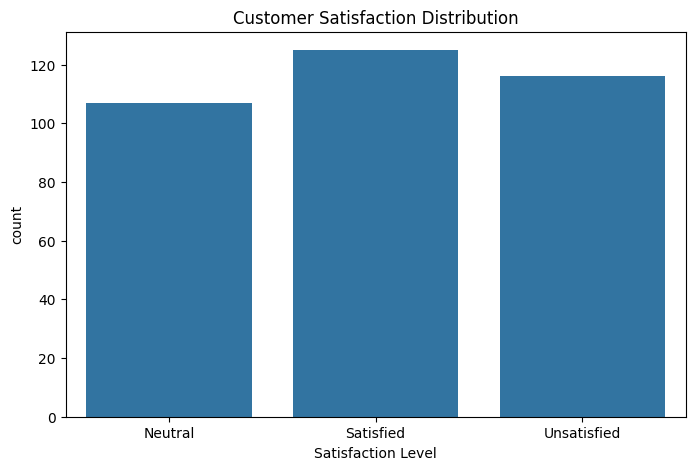

In [13]:
sns.countplot(x='Satisfaction Level',data=df)
plt.title('Customer Satisfaction Distribution')
plt.show()

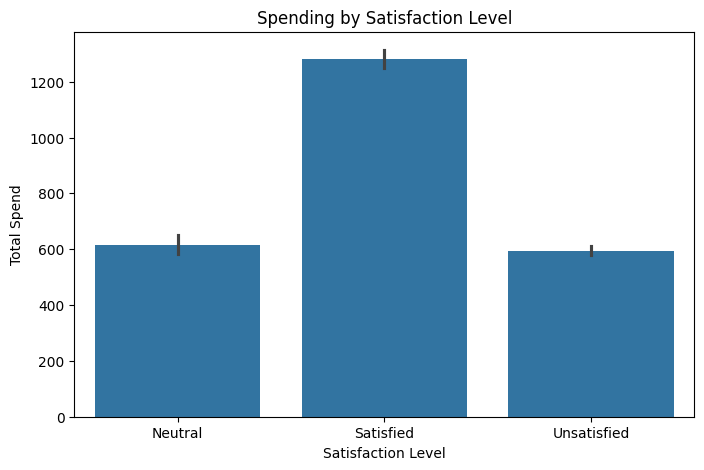

In [14]:
sns.barplot(x='Satisfaction Level',y='Total Spend',data=df)
plt.title('Spending by Satisfaction Level')
plt.show()

## 8. Discount Impact

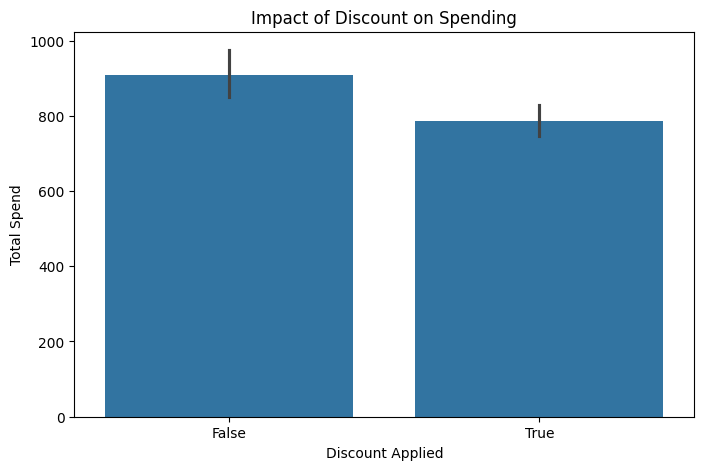

In [15]:
sns.barplot(x='Discount Applied',y='Total Spend',data=df)
plt.title('Impact of Discount on Spending')
plt.show()

## 9. Retention Risk Analysis

In [16]:
df['Churn Risk']=df['Days Since Last Purchase'].apply(lambda x:'High Risk' if x>60 else 'Low Risk')

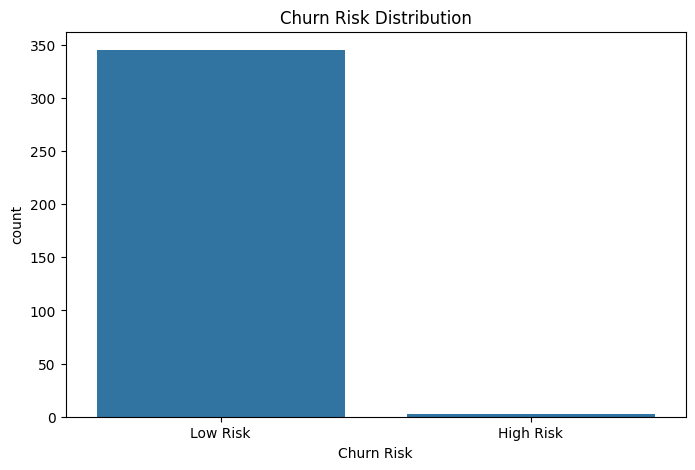

In [17]:
sns.countplot(x='Churn Risk',data=df)
plt.title('Churn Risk Distribution')
plt.show()

## 10. Correlation Analysis

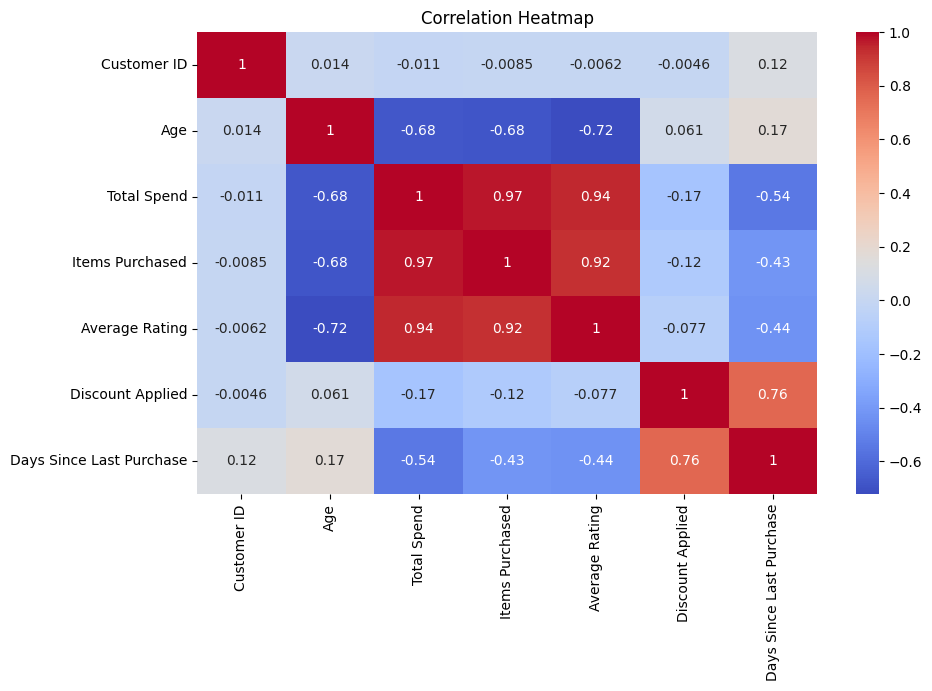

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 11. Example SQL Queries

```sql
SELECT Gender, COUNT(*) FROM customers GROUP BY Gender;

SELECT Membership_Type, AVG(Total_Spend) FROM customers GROUP BY Membership_Type;

SELECT City, AVG(Total_Spend) FROM customers GROUP BY City;

SELECT * FROM customers WHERE Days_Since_Last_Purchase > 60;

SELECT Discount_Applied, AVG(Total_Spend) FROM customers GROUP BY Discount_Applied;
```

## 12. Business Recommendations

- Send targeted offers to customers with high churn risk.
- Introduce loyalty programs for premium members.
- Use discounts strategically to boost engagement.
- Focus marketing efforts in high-spending cities.

## 13. Conclusion

This analysis highlights how demographic factors, membership tiers, and engagement patterns influence customer purchasing behavior. Using these insights, e‑commerce businesses can improve customer retention and design better marketing strategies.